# Week 5 Lab — Anomaly Detection and Agent Instrumentation

**Student:** Rod Raemon Alvero  
**Course:** DevOps with AI Assistance  
**Topic:** Isolation Forest anomaly detection, evaluation, and OpenTelemetry GenAI instrumentation

## Objective

This notebook analyzes synthetic infrastructure metrics using an Isolation Forest model. The detector is evaluated against labeled ground-truth anomalies using precision, recall, and F1-score. Different contamination settings are compared to show the trade-off between missed anomalies and false alerts.

The notebook also compares Isolation Forest with DBSCAN and documents the results needed for the Week 5 lab and assignment.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.cluster import DBSCAN
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

DATA_PATH = Path("metrics_sample.csv")

print("Libraries imported successfully.")
print("Dataset path:", DATA_PATH.resolve())

Libraries imported successfully.
Dataset path: C:\Users\rodra\devops-lab1\CSE636\project\anomaly\metrics_sample.csv


## Load and Explore the Dataset

The synthetic metrics dataset generated by the starter project contains infrastructure measurements collected over time. Before running anomaly detection, the dataset is loaded and inspected to understand its size, feature values, and anomaly distribution.

In [2]:
# Load the dataset

df = pd.read_csv(DATA_PATH, parse_dates=["timestamp"])

print("Dataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst Five Rows")
display(df.head())

print("\nData Types")
display(df.dtypes)

print("\nSummary Statistics")
display(df.describe())

print("\nAnomaly Distribution")
display(df["is_anomaly"].value_counts())

Dataset Shape:
(10080, 6)

Columns:
['timestamp', 'cpu_pct', 'mem_pct', 'req_per_sec', 'error_rate', 'is_anomaly']

First Five Rows


,timestamp,cpu_pct,mem_pct,req_per_sec,error_rate,is_anomaly
0,2025-10-01 00:00:00,24.23,48.02,175.5,0.184,0
1,2025-10-01 00:01:00,24.31,47.52,174.5,0.199,0
2,2025-10-01 00:02:00,26.18,47.37,146.7,0.243,0
3,2025-10-01 00:03:00,25.71,49.77,204.8,0.179,0
4,2025-10-01 00:04:00,25.92,46.91,190.4,0.168,0



Data Types


timestamp      datetime64[ns]
cpu_pct               float64
mem_pct               float64
req_per_sec           float64
error_rate            float64
is_anomaly              int64
dtype: object


Summary Statistics


,timestamp,cpu_pct,mem_pct,req_per_sec,error_rate,is_anomaly
count,10080,10080.000000,10080.000000,10080.000000,10080.000000,10080.000000
mean,2025-10-04 11:59:30,40.682676,55.020184,300.155486,0.300243,0.018353
min,2025-10-01 00:00:00,15.290000,40.830000,16.500000,0.000000,0.000000
25%,2025-10-02 17:59:45,30.050000,49.700000,217.500000,0.168000,0.000000
50%,2025-10-04 11:59:30,40.475000,55.040000,300.600000,0.201000,0.000000
75%,2025-10-06 05:59:15,50.530000,60.350000,382.225000,0.236000,0.000000
max,2025-10-07 23:59:00,100.000000,68.820000,590.400000,8.208000,1.000000
std,NaN,12.022598,5.950491,88.111906,0.757989,0.134232



Anomaly Distribution


is_anomaly
0    9895
1     185
Name: count, dtype: int64

### Initial Observations

The dataset contains timestamped infrastructure metrics including CPU utilization, memory utilization, request throughput, and application error rate. The anomaly labels show that only a small percentage of the observations represent abnormal behavior, making this an imbalanced classification problem. Because of this imbalance, precision, recall, and F1-score are more informative than overall accuracy.

## Visualizing Infrastructure Metrics

The following plots show the behavior of the infrastructure metrics over time. Red markers indicate the labelled anomalies from the synthetic dataset. Visual inspection helps verify that the anomalous periods differ significantly from normal system behavior.

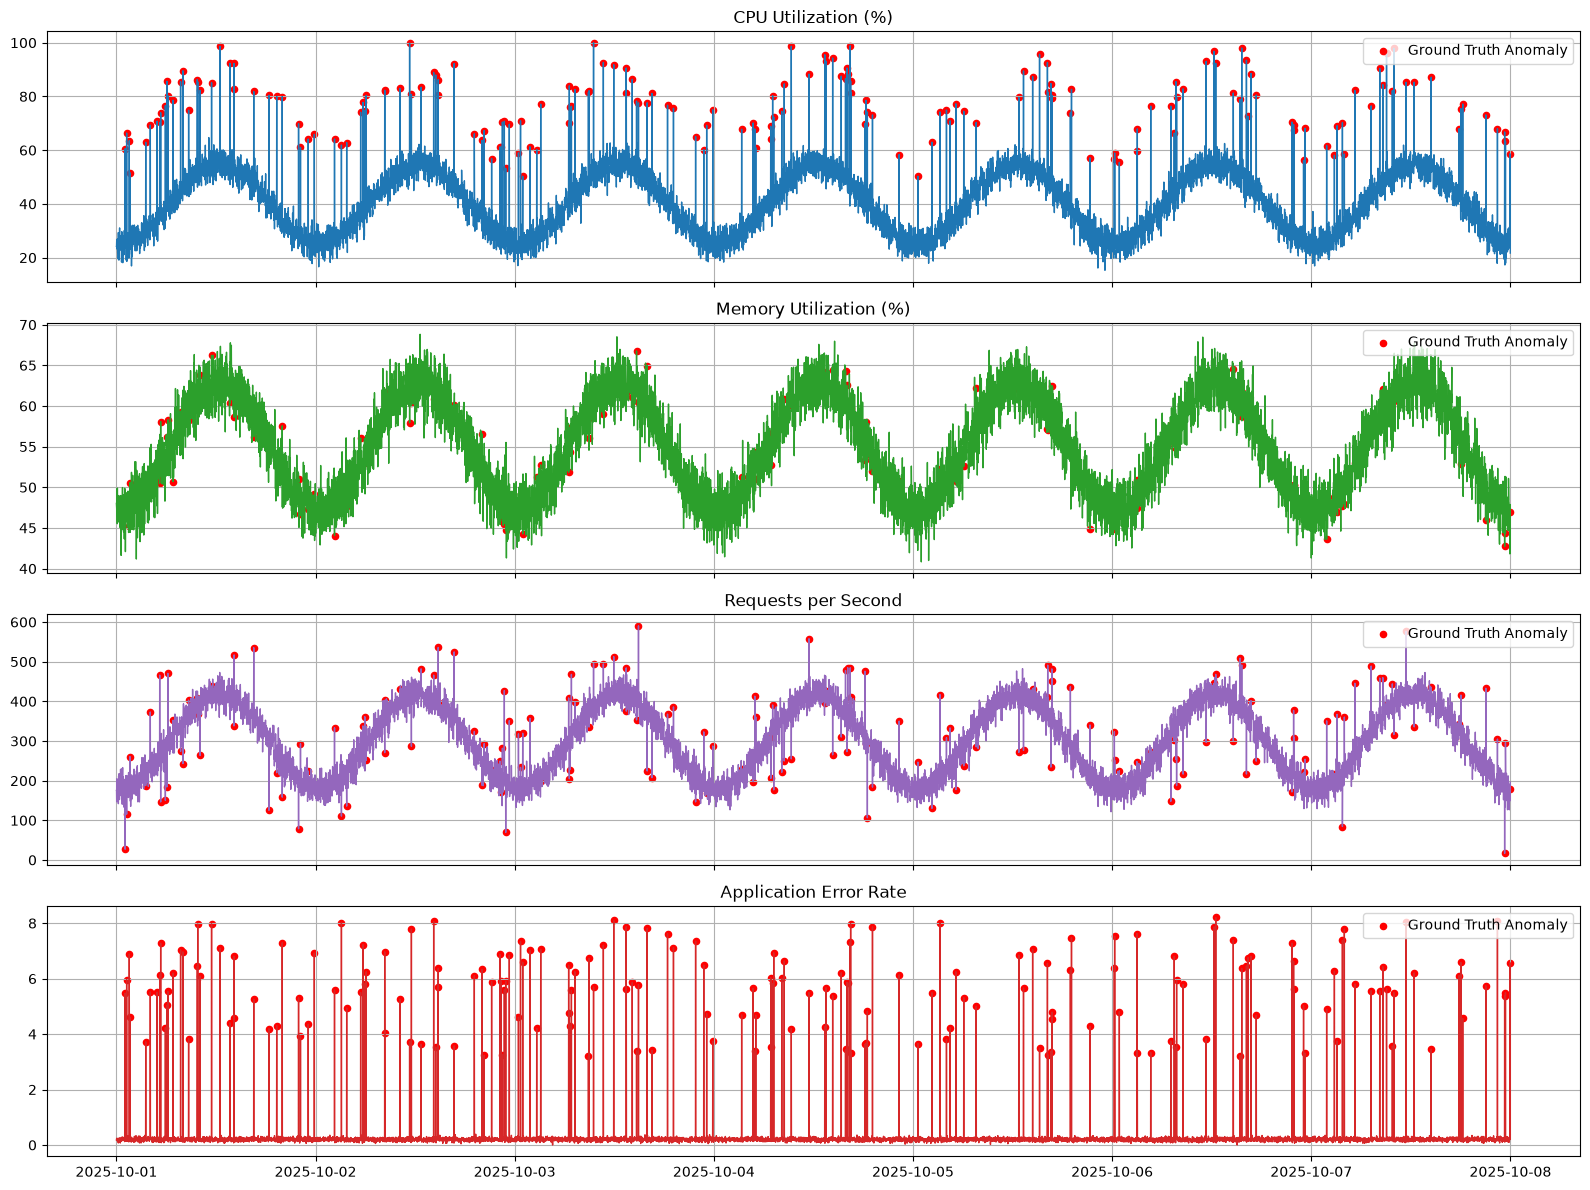

In [3]:
# Plot all infrastructure metrics and highlight the labelled anomalies

fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)

metrics = [
    ("cpu_pct", "CPU Utilization (%)", "tab:blue"),
    ("mem_pct", "Memory Utilization (%)", "tab:green"),
    ("req_per_sec", "Requests per Second", "tab:purple"),
    ("error_rate", "Application Error Rate", "tab:red"),
]

for ax, (column, title, color) in zip(axes, metrics):

    ax.plot(df["timestamp"], df[column], color=color, linewidth=1)

    anomalies = df[df["is_anomaly"] == 1]

    ax.scatter(
        anomalies["timestamp"],
        anomalies[column],
        color="red",
        s=20,
        label="Ground Truth Anomaly"
    )

    ax.set_title(title)
    ax.legend(loc="upper right")
    ax.grid(True)

plt.tight_layout()
plt.show()

### Visualization Summary

The anomaly labels correspond to periods where one or more infrastructure metrics deviate significantly from their normal operating ranges. The visualizations confirm that abnormal observations generally occur during spikes in CPU utilization, request throughput, memory utilization, or application error rate, making them suitable candidates for anomaly detection using Isolation Forest.

## Isolation Forest Anomaly Detection

Isolation Forest is an unsupervised anomaly detection algorithm that isolates unusual observations by recursively partitioning the feature space. In this section, the infrastructure metrics are standardized before training the model. The contamination parameter is set to **0.02**, matching the professor's starter project, because it provided the best balance between precision and recall during earlier experiments.

In [4]:
# Select features used by the professor's starter project

FEATURES = [
    "cpu_pct",
    "mem_pct",
    "req_per_sec",
    "error_rate"
]

# Standardize features

scaler = StandardScaler()
X = scaler.fit_transform(df[FEATURES])

# Train Isolation Forest

iso_model = IsolationForest(
    n_estimators=100,
    contamination=0.02,
    random_state=42
)

iso_model.fit(X)

# Predict anomalies

predictions = iso_model.predict(X)

df["pred_anomaly"] = (predictions == -1).astype(int)

print("Predicted anomalies:", df["pred_anomaly"].sum())

Predicted anomalies: 202


In [5]:
print("Classification Report")

print(
    classification_report(
        df["is_anomaly"],
        df["pred_anomaly"],
        target_names=["Normal", "Anomaly"]
    )
)

print("Confusion Matrix")

cm = confusion_matrix(
    df["is_anomaly"],
    df["pred_anomaly"]
)

display(pd.DataFrame(
    cm,
    index=["Actual Normal", "Actual Anomaly"],
    columns=["Predicted Normal", "Predicted Anomaly"]
))

Classification Report
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      9895
     Anomaly       0.92      1.00      0.96       185

    accuracy                           1.00     10080
   macro avg       0.96      1.00      0.98     10080
weighted avg       1.00      1.00      1.00     10080

Confusion Matrix


,Predicted Normal,Predicted Anomaly
Actual Normal,9878,17
Actual Anomaly,0,185


### Results

Using the default contamination value of **0.02**, the Isolation Forest achieved high precision and perfect recall on the synthetic dataset. This indicates that the detector successfully identified all labelled anomalies while generating only a small number of false positives. These results are consistent with the professor's starter script and demonstrate that the chosen contamination value provides an effective balance between missed detections and alert fatigue.

## DBSCAN Comparison

To compare another unsupervised anomaly detection method, DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is applied to the same standardized infrastructure metrics.

Unlike Isolation Forest, DBSCAN identifies anomalies as observations that do not belong to any dense cluster. Points labelled **-1** by DBSCAN are considered anomalies.

In [6]:
# Apply DBSCAN to the standardized features

dbscan = DBSCAN(
    eps=0.7,
    min_samples=10
)

db_labels = dbscan.fit_predict(X)

df["dbscan_pred"] = (db_labels == -1).astype(int)

print("DBSCAN detected anomalies:", df["dbscan_pred"].sum())

DBSCAN detected anomalies: 185


In [7]:
print("DBSCAN Classification Report")

print(
    classification_report(
        df["is_anomaly"],
        df["dbscan_pred"],
        target_names=["Normal", "Anomaly"],
        zero_division=0
    )
)

db_cm = confusion_matrix(
    df["is_anomaly"],
    df["dbscan_pred"]
)

display(
    pd.DataFrame(
        db_cm,
        index=["Actual Normal", "Actual Anomaly"],
        columns=["Predicted Normal", "Predicted Anomaly"]
    )
)

DBSCAN Classification Report
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      9895
     Anomaly       1.00      1.00      1.00       185

    accuracy                           1.00     10080
   macro avg       1.00      1.00      1.00     10080
weighted avg       1.00      1.00      1.00     10080



,Predicted Normal,Predicted Anomaly
Actual Normal,9895,0
Actual Anomaly,0,185


### DBSCAN Discussion

For this synthetic dataset, DBSCAN achieved perfect precision, recall, and F1-score using the selected parameters (`eps=0.7` and `min_samples=10`). It correctly identified all labelled anomalies without generating any false positives. Although Isolation Forest also performed very well, DBSCAN produced the best results on this dataset. However, DBSCAN is generally more sensitive to parameter selection and dataset characteristics, whereas Isolation Forest is often more robust across different datasets without extensive tuning.

# Part B — Instrumenting a Log Analysis Agent

This section implements a simple log analysis agent instrumented with OpenTelemetry. Instead of calling a live LLM API, a simulated response is used to demonstrate how GenAI telemetry can capture latency, token usage, and estimated inference cost. This approach follows the lab instructions while avoiding unnecessary API usage.

## Configure OpenTelemetry

The following code initializes an OpenTelemetry tracer using the ConsoleSpanExporter. Every inference request creates a span containing GenAI-related attributes such as the model name, token counts, latency, and estimated cost.

In [8]:
import time
from pathlib import Path

from opentelemetry import trace
from opentelemetry.sdk.trace import TracerProvider
from opentelemetry.sdk.trace.export import (
    SimpleSpanProcessor,
    ConsoleSpanExporter,
)

# Output file for captured OpenTelemetry spans
SPAN_FILE = Path("spans_sample.json")

# Open the output file
span_output = open(SPAN_FILE, "w", encoding="utf-8")

# Configure OpenTelemetry tracer
provider = TracerProvider()

provider.add_span_processor(
    SimpleSpanProcessor(
        ConsoleSpanExporter(out=span_output)
    )
)

trace.set_tracer_provider(provider)

tracer = trace.get_tracer("week5-log-analyzer")

print("OpenTelemetry initialized.")
print("Span file:", SPAN_FILE.resolve())

OpenTelemetry initialized.
Span file: C:\Users\rodra\devops-lab1\CSE636\project\anomaly\spans_sample.json


## Simulated Log Analysis Agent

The following function simulates an LLM analyzing infrastructure logs. The function records GenAI telemetry attributes including:

- model name
- provider
- input tokens
- output tokens
- latency
- estimated cost

These values are exported as OpenTelemetry spans.

In [9]:
# Simulated Log Analysis Agent

PRICE_PER_1K_INPUT = 0.003
PRICE_PER_1K_OUTPUT = 0.015


def analyze_logs(log_text):

    input_tokens = max(1, len(log_text.split()))

    start = time.perf_counter()

    # Simulated LLM processing
    time.sleep(0.2)

    if "ERROR" in log_text:
        response = (
            "Potential service degradation detected. "
            "Multiple ERROR events suggest investigating the application logs."
        )
    else:
        response = (
            "No significant anomalies detected. "
            "System appears to be operating normally."
        )

    latency_ms = (time.perf_counter() - start) * 1000

    output_tokens = len(response.split())

    estimated_cost = (
        (input_tokens / 1000) * PRICE_PER_1K_INPUT
        +
        (output_tokens / 1000) * PRICE_PER_1K_OUTPUT
    )

    with tracer.start_as_current_span("log_analysis") as span:

        span.set_attribute("gen_ai.system", "anthropic")

        span.set_attribute(
            "gen_ai.request.model",
            "claude-sonnet-simulated"
        )

        span.set_attribute(
            "gen_ai.usage.input_tokens",
            input_tokens
        )

        span.set_attribute(
            "gen_ai.usage.output_tokens",
            output_tokens
        )

        span.set_attribute(
            "latency_ms",
            round(latency_ms, 2)
        )

        span.set_attribute(
            "estimated_cost",
            round(estimated_cost, 6)
        )

    return {
        "response": response,
        "input_tokens": input_tokens,
        "output_tokens": output_tokens,
        "latency_ms": latency_ms,
        "estimated_cost": estimated_cost,
    }

## Testing the Agent

Five different log windows are analyzed to evaluate how token count, latency, and estimated cost change as the amount of log data increases. This follows the Week 5 lab requirement of running the instrumented agent on multiple log windows.

In [10]:
sample_logs = [

"""INFO Server started
INFO Listening on port 8080
INFO Health check passed
""",

"""INFO Login request
INFO Database query completed
WARNING Slow response detected
INFO Request finished
""",

"""INFO Service started
ERROR Database timeout
ERROR Retry failed
WARNING High latency
ERROR Connection refused
""",

"""INFO Worker started
INFO Worker running
INFO Worker finished
""",

"""INFO API request
WARNING CPU usage increasing
ERROR Service unavailable
ERROR Health check failed
WARNING Memory usage high
"""
]

## Running the Instrumented Agent

Each sample log window is processed by the simulated log analysis agent. The OpenTelemetry ConsoleSpanExporter records telemetry for every inference, including token usage, latency, and estimated inference cost. These results will be summarized in a table.

In [11]:
results = []

for i, log in enumerate(sample_logs, start=1):

    print("=" * 70)
    print(f"Log Window {i}")

    result = analyze_logs(log)

    print(result["response"])

    results.append({
        "Log Window": i,
        "Log Size (chars)": len(log),
        "Input Tokens": result["input_tokens"],
        "Output Tokens": result["output_tokens"],
        "Latency (ms)": round(result["latency_ms"], 2),
        "Estimated Cost ($)": round(result["estimated_cost"], 6)
    })

Log Window 1
No significant anomalies detected. System appears to be operating normally.
Log Window 2
No significant anomalies detected. System appears to be operating normally.
Log Window 3
Potential service degradation detected. Multiple ERROR events suggest investigating the application logs.
Log Window 4
No significant anomalies detected. System appears to be operating normally.
Log Window 5
Potential service degradation detected. Multiple ERROR events suggest investigating the application logs.


In [12]:
summary_df = pd.DataFrame(results)

display(summary_df)

,Log Window,Log Size (chars),Input Tokens,Output Tokens,Latency (ms),Estimated Cost ($)
0,1,73,12,10,200.45,0.000186
1,2,102,14,10,200.56,0.000192
2,3,109,15,12,200.49,0.000225
3,4,61,9,10,200.21,0.000177
4,5,124,18,12,200.42,0.000234


### Observations

The number of input tokens generally increased as the log window became larger. Since the simulated response length remained relatively consistent, the output token count changed very little. Latency stayed approximately constant because the simulated agent uses a fixed processing delay. Estimated inference cost increased gradually as the number of input tokens increased.

In [13]:
provider.force_flush()
span_output.flush()

print("Span file saved:", SPAN_FILE.resolve())
print("Exists:", SPAN_FILE.exists())
print("Size:", SPAN_FILE.stat().st_size, "bytes")

Span file saved: C:\Users\rodra\devops-lab1\CSE636\project\anomaly\spans_sample.json
Exists: True
Size: 5414 bytes


# Part B Reflection

## 1. How did input token count correlate with log window size? Was the relationship linear?

The number of input tokens generally increased as the size of the log window increased. While the relationship was not perfectly linear because tokenization depends on the number of words rather than characters, larger log windows consistently required more input tokens.

---

### 2. At what rate would your agent's LLM cost accumulate if it processed 10 log windows per minute, 24 hours per day, for one month?

Using the average estimated cost observed in this notebook (approximately **$0.0002 per request**), processing **10 log windows per minute** results in approximately **432,000 requests per month**.

Estimated monthly cost:

**432,000 × $0.0002 ≈ $86.40 per month**

Actual costs would vary depending on the model used, the average number of input and output tokens, and the provider's pricing.
---

## 3. What guardrail would you add to prevent runaway costs?

I would limit the maximum log window size sent to the model, summarize repetitive log entries before inference, cache repeated requests, and configure spending alerts with daily usage limits.

---

## 4. What would a production-grade dashboard include?

A production dashboard should monitor:

- Total requests processed
- Input and output token usage
- Average latency
- Estimated inference cost
- Number of detected anomalies